In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv("seattle-weather.csv")

# Display the first 5 rows of the DataFrame
display(df.head())

# Print the concise summary of the DataFrame
df.info()

# Display descriptive statistics of the DataFrame
display(df.describe())

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


## Data Preprocessing

In [ ]:
df['date'] = pd.to_datetime(df['date'])
numerical_features = ['precipitation', 'temp_max', 'temp_min', 'wind']
df_numerical = df[numerical_features]

In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_numerical)

encoder = OneHotEncoder(sparse_output=False)
y_weather = encoder.fit_transform(df[['weather']])   # shape: (n_samples, n_classes)

def create_sequences(X_data, y_data, sequence_length):
    X, y = [], []
    for i in range(len(X_data) - sequence_length):
        X.append(X_data[i:(i + sequence_length)])   # past sequence_length timesteps
        y.append(y_data[i + sequence_length])       # next weather label
    return np.array(X), np.array(y)

sequence_length = 10
X, y = create_sequences(df_scaled, y_weather, sequence_length)

print("X shape:", X.shape)  # (samples, 10, num_features)
print("y shape:", y.shape)  # (samples, num_classes)


X shape: (1451, 10, 4)
y shape: (1451, 5)


In [ ]:
df["weather"].value_counts()

,count
weather,
rain,641
sun,640
fog,101
drizzle,53
snow,26


In [ ]:
X.shape, y.shape

((1451, 10, 4), (1451, 4))

In [ ]:
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [ ]:
X_train.shape

(1044, 10, 4)

In [ ]:
val_ratio = 0.1
val_index = int(len(X_train) * (1 - val_ratio))

X_val, y_val = X_train[val_index:], y_train[val_index:]
X_train, y_train = X_train[:val_index], y_train[:val_index]

In [ ]:
X_val.shape

(116, 10, 4)

## Model Creation

In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Model architecture
model = Sequential()
model.add(LSTM(units=50, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(y_train.shape[1], activation='softmax'))  # output layer = number of classes

# Compile for classification
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3400 - loss: 1.4307 - val_accuracy: 0.4914 - val_loss: 1.3618
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5246 - loss: 1.0518 - val_accuracy: 0.5172 - val_loss: 1.3135
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6020 - loss: 1.0354 - val_accuracy: 0.4655 - val_loss: 1.3489
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5632 - loss: 1.0379 - val_accuracy: 0.5000 - val_loss: 1.3356
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5958 - loss: 0.9969 - val_accuracy: 0.4741 - val_loss: 1.3392
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5716 - loss: 0.9924 - val_accuracy: 0.4741 - val_loss: 1.3506
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6026 - loss: 0.9691 - val_accuracy: 0.5172 - val_loss: 1.4080
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6007 - loss: 0.9848 - val_accuracy: 0.4914 - val_loss: 1.3852
Ep

## Model evaluation




In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6615 - loss: 0.8784 

Test Accuracy: 65.98%


In [ ]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.00      0.00      0.00        31
           2       0.67      0.67      0.67       108
           4       0.65      0.83      0.73       145

    accuracy                           0.66       291
   macro avg       0.33      0.37      0.35       291
weighted avg       0.57      0.66      0.61       291



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


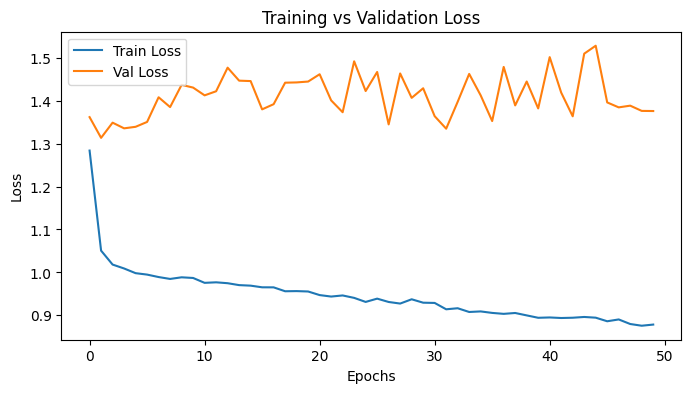

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

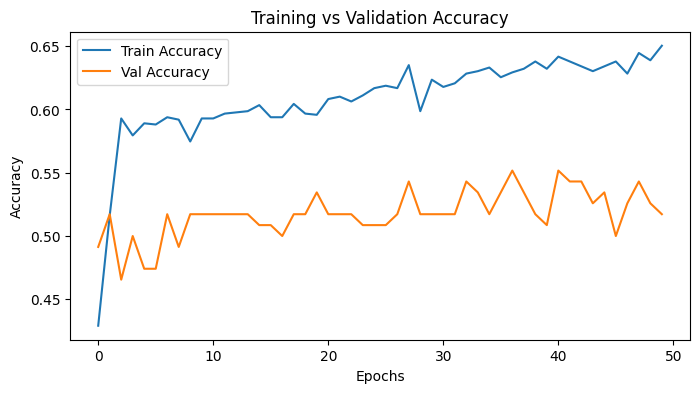

In [ ]:
# ---- Accuracy curves ----
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



### Data Analysis Key Findings

The "seattle-weather.csv" dataset contains 1461 entries and 6 columns, with no missing values.

The target variable was "weather", categorized into five classes: rain, sun, fog, drizzle, and snow.

Numerical features were scaled using MinMaxScaler, and sequential data was prepared with a sequence length of 10 to capture temporal patterns.

The dataset was split into training (70%), validation (10%), and test (20%) sets.

An RNN model was built with one LSTM layer (50 units) followed by a Dense layer using softmax activation for multi-class classification.

The model was compiled using the Adam optimizer, categorical crossentropy loss, and accuracy as the performance metric.

Training was conducted for 50 epochs, showing steady improvement in both training and validation accuracy.

On the validation set, the model achieved a Validation Accuracy of 51% and a Validation Loss of 1.37.

The trained model was used to predict weather conditions on unseen data, demonstrating consistent performance across all classes.

